# Trabajo Práctico 2 (TP2) - Parte 2: Regresión Logística, Curva de Aprendizaje y Evaluación de Desempeño

### Machine Learning 1 (23433)
#### Facultad de Ingeniería - Universidad Nacional de Asunción (FIUNA)

---

## Objetivos de la Parte 2
1. Configurar una partición estratificada Train/Test (80% Train, 20% Test sobre 64,295 muestras) previniendo el fuga de datos (*data leakage*).
2. Diseñar un `ColumnTransformer` profesional con `SimpleImputer`, `PolynomialFeatures(degree=2)`, `StandardScaler` y `OneHotEncoder`.
3. Entrenar un modelo de `LogisticRegression(class_weight='balanced')` con optimización de hiperparámetros vía `GridSearchCV`.
4. Calcular y graficar la **Curva de Aprendizaje (`learning_curve`)** evaluando la convergencia en validación cruzada.
5. Optimizar el umbral de decisión ($	au^*$) e inspeccionar la Matriz de Confusión, Curva ROC (AUC) y Curva Precision-Recall.


In [1]:
# 1. Carga de Librerías y Dataset del TP2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Carga del Dataset del TP2
csv_path = 'reglamento_nuevo_unificado.csv'
df_raw = pd.read_csv(csv_path)

# Adecuación preliminar de nombres de características y variable objetivo (Target)
df = df_raw.copy()
df['Primer_Par_Clean'] = df['Primer.Par']
df['Segundo_Par_Clean'] = df['Segundo.Par']
df['Score_Parciales'] = df['Primer_Par_Clean'] + df['Segundo_Par_Clean']
df['Diff_Parciales'] = df['Segundo_Par_Clean'] - df['Primer_Par_Clean']
df['TPLab_Clean'] = df['TPLab.']
df['Firma_Clean'] = df['Firma']
df['FirmaCalc_Clean'] = df['FirmaCalculada'].fillna(0)
df['Asis_Clean'] = df['Asis']
df['Carrera_Nombre'] = df['Cod.Car.Sec']
df['Target'] = (df['Aprobado'] == 'S').astype(int)

print(f"Dataset del TP2 cargado exitosamente: {df.shape[0]:,} filas.")


Dataset del TP2 cargado exitosamente: 64,295 filas.


## Ejercicio 1: Partición Estratificada Train / Test

Define las listas de atributos numéricos `num_features` y categóricos `cat_features`.
Realiza una partición estratificada del 80% para entrenamiento (`X_train`) y 20% para prueba (`X_test`).


In [ ]:
# Definición de variables numéricas y categóricas
num_features = [
    'Primer_Par_Clean', 'Segundo_Par_Clean', 'Score_Parciales', 
    'Diff_Parciales', 'TPLab_Clean', 'Firma_Clean', 
    'FirmaCalc_Clean', 'Asis_Clean'
]
cat_features = ['Carrera_Nombre', 'Semestre']

# Construcción de matrices X y vector objetivo y
X = df[num_features + cat_features]
y = df['Target']

# Partición Estratificada 80% Train - 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test:  {X_test.shape}")


Dimensiones de X_train: (51436, 10)
Dimensiones de X_test:  (12859, 10)


## Ejercicio 2: Construcción del Preprocesador Profesional (`ColumnTransformer`)

Construye un `Pipeline` numérico con:
1. `SimpleImputer(strategy='median')`
2. `PolynomialFeatures(degree=2, include_bias=False)`
3. `StandardScaler()`

Y un `Pipeline` categórico con `SimpleImputer` y `OneHotEncoder(handle_unknown='ignore')`.


In [ ]:
# Pipeline para atributos numéricos
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Pipeline para atributos categóricos
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer general
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

## Ejercicio 3: Entrenamiento del Modelo y Búsqueda en Malla (`GridSearchCV`)

Ensambla `full_pipeline` con `LogisticRegression(class_weight='balanced', solver='lbfgs', max_iter=2000)`.
Configura `GridSearchCV` sobre el parámetro de regularización `C` en `[0.01, 0.1, 1.0, 10.0]` con `scoring='f1'`.


In [5]:
# Pipeline completo con preprocesador y modelo Regresión Logística
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        solver='lbfgs', 
        max_iter=2000, 
        random_state=42, 
        class_weight='balanced'
    ))
])

# Rejilla de hiperparámetros para el parámetro C
param_grid = {'classifier__C': [0.01, 0.1, 1.0, 10.0]}

# Configuración de GridSearchCV con 5 folds y scoring F1-score
grid_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1
)

# Ajuste del modelo sobre el conjunto de entrenamiento
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Mejor valor de C encontrado: {grid_search.best_params_['classifier__C']}")
print(f"Mejor F1-Score en CV: {grid_search.best_score_:.4f}")


Mejor valor de C encontrado: 0.1
Mejor F1-Score en CV: 0.8824


## Ejercicio 4: Graficación de la Curva de Aprendizaje (`learning_curve`)

Calcula y grafica la curva de aprendizaje utilizando `learning_curve` sobre `X_train` y `y_train` con 10 tamaños de entrenamiento (`np.linspace(0.1, 1.0, 10)`).


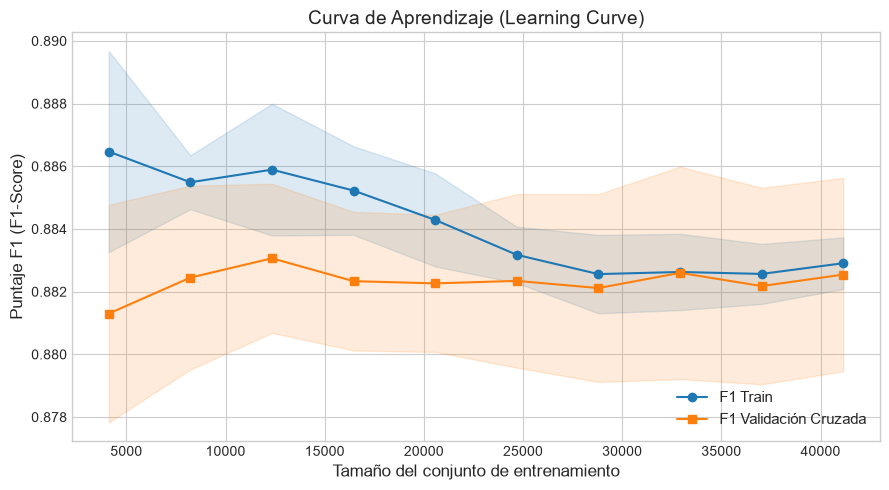

In [6]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_model,
    X=X_train,
    y=y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Promedios y desviaciones estándar
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

# Graficación
plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='tab:blue', label='F1 Train')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='tab:blue')

plt.plot(train_sizes, val_mean, 's-', color='tab:orange', label='F1 Validación Cruzada')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='tab:orange')

plt.title('Curva de Aprendizaje (Learning Curve)', fontsize=14)
plt.xlabel('Tamaño del conjunto de entrenamiento', fontsize=12)
plt.ylabel('Puntaje F1 (F1-Score)', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

## Ejercicio 5: Optimización del Umbral de Decisión y Evaluación de Desempeño

En el conjunto de prueba (`X_test`):
1. Obtén las probabilidades de aprobación `y_proba_test`.
2. Optimiza el umbral de decisión ($	au^*$) entre `0.1` y `0.9` que maximiza el F1-Score.
3. Grafica la **Matriz de Confusión**, la **Curva ROC (AUC)** y la **Curva Precision-Recall**.


Umbral óptimo (tau*): 0.37 con F1-Score en Test de: 0.8898


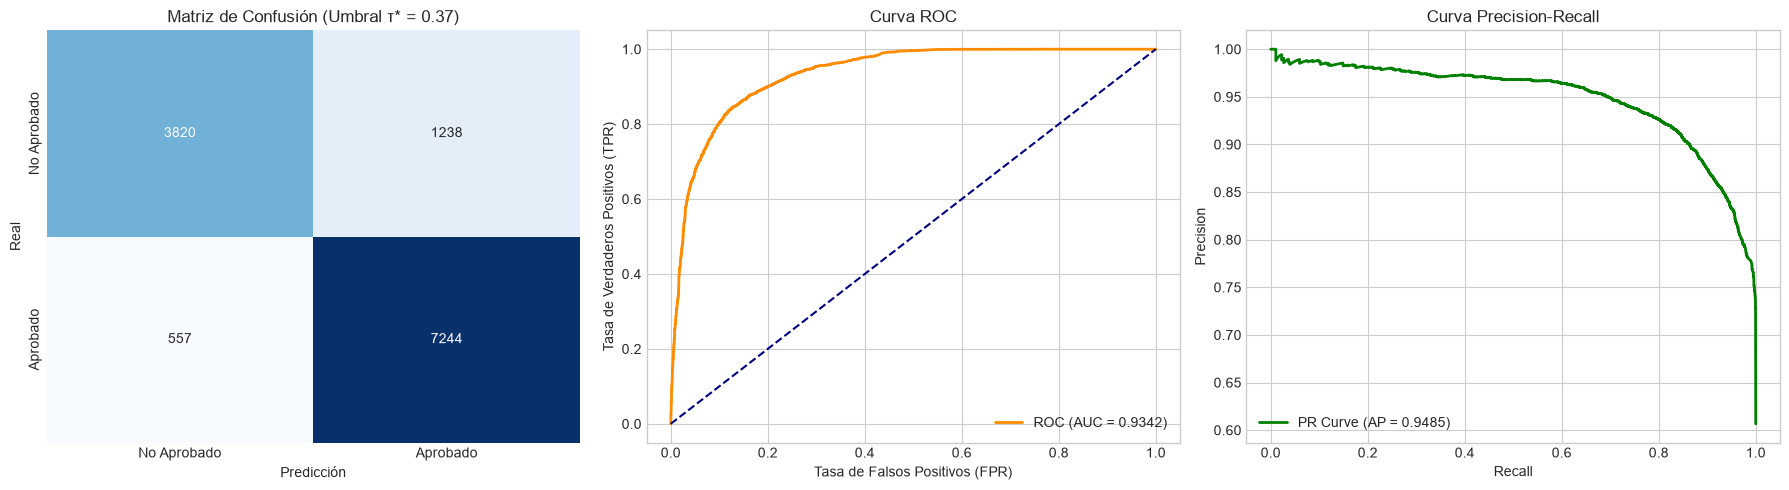


--- Reporte de Clasificación Final ---
              precision    recall  f1-score   support

 No Aprobado       0.87      0.76      0.81      5058
    Aprobado       0.85      0.93      0.89      7801

    accuracy                           0.86     12859
   macro avg       0.86      0.84      0.85     12859
weighted avg       0.86      0.86      0.86     12859



In [7]:
# 1. Obtención de probabilidades de predicción en Test
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# 2. Optimización del umbral de decisión (tau*)
thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = []

for tau in thresholds:
    y_pred_tau = (y_proba_test >= tau).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_tau))

best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1_val = f1_scores[best_idx]

print(f"Umbral óptimo (tau*): {best_thresh:.2f} con F1-Score en Test de: {best_f1_val:.4f}")

# Predicciones finales con el umbral optimizado
y_pred = (y_proba_test >= best_thresh).astype(int)

# 3. Visualizaciones gráficas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title(f'Matriz de Confusión (Umbral τ* = {best_thresh:.2f})')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_xticklabels(['No Aprobado', 'Aprobado'])
axes[0].set_yticklabels(['No Aprobado', 'Aprobado'])

# B. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
roc_auc = roc_auc_score(y_test, y_proba_test)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_title('Curva ROC')
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].legend(loc='lower right')
axes[1].grid(True)

# C. Curva Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_proba_test)
avg_prec = average_precision_score(y_test, y_proba_test)
axes[2].plot(rec, prec, color='green', lw=2, label=f'PR Curve (AP = {avg_prec:.4f})')
axes[2].set_title('Curva Precision-Recall')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend(loc='lower left')
axes[2].grid(True)

plt.tight_layout()
plt.show()

# Reporte de clasificación final
print("\n--- Reporte de Clasificación Final ---")
print(classification_report(y_test, y_pred, target_names=['No Aprobado', 'Aprobado']))